In [2]:
from network import SupplyChainNetwork
from Graphclass_module import Graphclass
from time import perf_counter
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
%run network
%run Graphclass_module

In [3]:
sc = SupplyChainNetwork.generate(num_nodes=2, num_edges=2, num_colors=2)

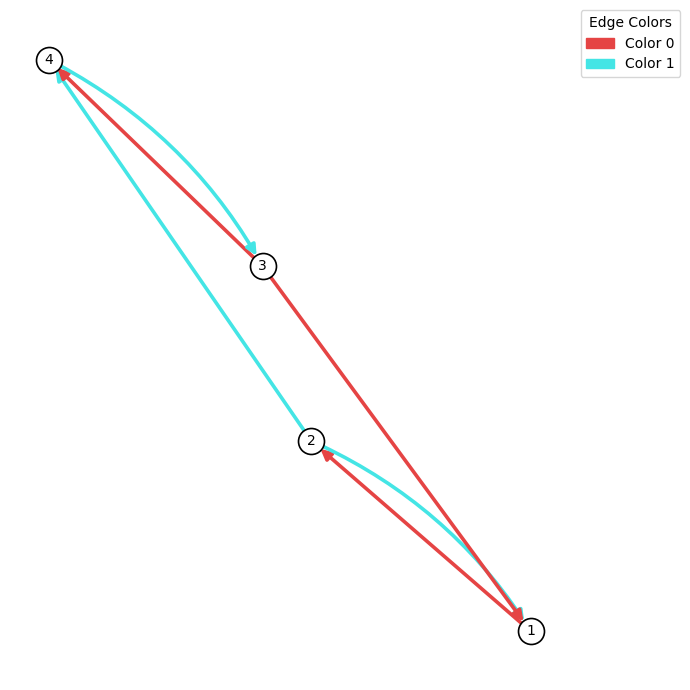

In [15]:
G = nx.MultiDiGraph()
G.add_edge(1, 2, weight=1, color=0)
G.add_edge(2, 1, weight=1, color=1)
G.add_edge(3, 1, weight=1, color=0)
G.add_edge(2, 4, weight=1, color=1)
G.add_edge(3, 4, weight=1, color=0)
G.add_edge(4, 3, weight=1, color=1)

sc.G = G
sc.visualize_supply_chain()

In [16]:
# Get edge colors from attributes
edge_colors = [G[u][v]["color"] for u, v in G.edges()]

# Layout
pos = nx.spring_layout(G)

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=2000)

# Draw edges with their assigned colors
nx.draw_networkx_edges(
    G,
    pos,
    edge_color=edge_colors,
    arrows=True,
    arrowstyle='-|>',
    arrowsize=20,
    width=2
)
# Draw node labels (node names)
nx.draw_networkx_labels(G, pos)

plt.axis("off")
plt.show()

KeyError: 'color'

In [29]:
sc = SupplyChainNetwork.from_file("08_25_2025_subgraph_edgelist.csv")

In [30]:
np.log(sc.num_edges) / np.log(sc.num_nodes)

np.float64(1.0584642847962766)

### Look at how rows in color decomposition averages in diversification

In [4]:
len(max(nx.strongly_connected_components(sc.G), key=len))

4825

(array([0.56781705, 0.07452177, 0.0365223 , 0.04008148, 0.1049609 ,
        0.02628675, 0.28871225, 0.00395464]),
 array([0.   , 0.875, 1.75 , 2.625, 3.5  , 4.375, 5.25 , 6.125, 7.   ]),
 <BarContainer object of 8 artists>)

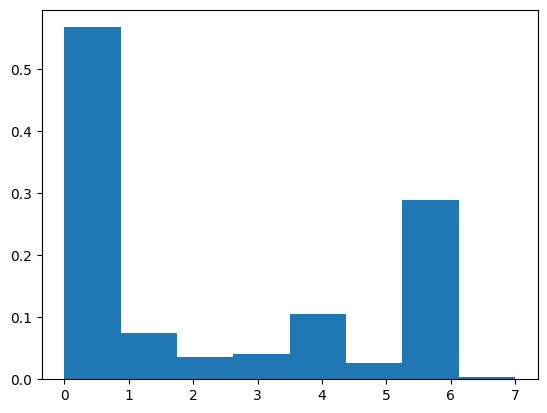

In [40]:
from scipy import stats 

plt.hist(list(d['color'] for _, _, d in sc.G.edges(data=True)), bins=8, density=True)

In [30]:
largest_wcc = max(nx.weakly_connected_components(sc.G), key=len)

G_lwcc = sc.G.subgraph(largest_wcc).copy()

sc.G.remove_nodes_from(set(sc.G) - largest_wcc)

sc.num_nodes = sc.G.number_of_nodes()
sc.num_edges = sc.G.number_of_edges()
sc.num_nodes

51496

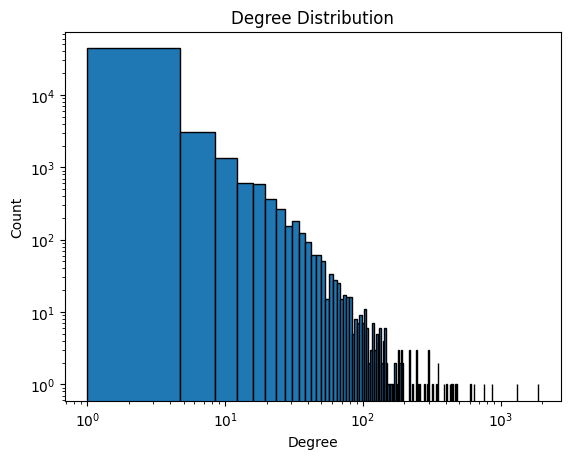

In [23]:
degrees = [d for _, d in sc.G.degree()]

fig, ax = plt.subplots()

ax.hist(degrees, bins=500, edgecolor='black')
ax.set_xscale('log')
ax.set_yscale('log')
plt.xlabel("Degree")
plt.ylabel("Count")
plt.title("Degree Distribution")
plt.show()

In [17]:
def alpha_mle_discrete_approx(x, kmin):
    x = x[x >= kmin]
    return 1 + len(x) / np.sum(np.log(x / (kmin - 0.5)))

def ks_distance_tail(x, kmin, alpha):
    # empirical CDF on tail
    xt = np.sort(x[x >= kmin])
    n = len(xt)
    if n == 0:
        return np.inf

    # model CDF for continuous approx: P(X<=t | X>=kmin) = 1 - (t/kmin)^{-(alpha-1)}
    # evaluated at observed points
    ecdf = np.arange(1, n + 1) / n
    model_cdf = 1 - (xt / kmin) ** (-(alpha - 1))

    return np.max(np.abs(ecdf - model_cdf))

def fit_powerlaw_tail(degrees, kmin_candidates=None):
    x = np.asarray(degrees, dtype=float)
    x = x[x > 0]

    if kmin_candidates is None:
        # common: only consider candidate kmins where tail has enough points
        kmin_candidates = np.unique(x.astype(int))

    best = {"kmin": None, "alpha": None, "ks": np.inf, "n_tail": 0}

    for kmin in kmin_candidates:
        xt = x[x >= kmin]
        if len(xt) < 50:  # heuristic: avoid tiny tails
            continue
        if kmin <= 1:
            continue

        alpha = alpha_mle_discrete_approx(x, kmin)
        ks = ks_distance_tail(x, kmin, alpha)

        if ks < best["ks"]:
            best = {"kmin": int(kmin), "alpha": float(alpha), "ks": float(ks), "n_tail": int(len(xt))}

    return best

In [ ]:
degrees = [d for _, d in sc.G.degree()]
best = fit_powerlaw_tail(degrees)
print(best)

{'kmin': 56, 'alpha': 2.722014790398635, 'ks': 0.028638019427970285, 'n_tail': 302}


In [10]:
bloomberg_edge_coeff = np.log(sc.num_edges) / np.log(sc.num_nodes)

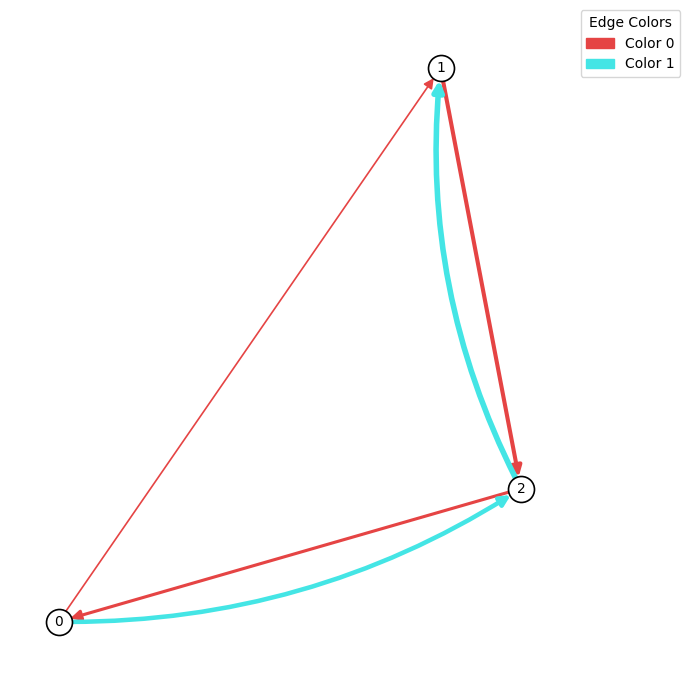

In [48]:
n1 = SupplyChainNetwork(3, 5, 2)
n1.visualize_supply_chain()

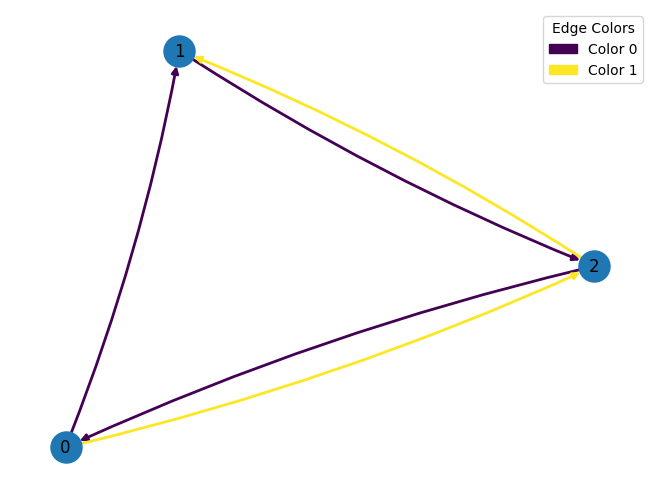

In [49]:
n2 = Graphclass(1, 1, 1, "random")
W = nx.to_numpy_array(n1.G, weight="weight")

n2.use_premade(n1.G, W)
n2.visualize_graph(n2.G)

4


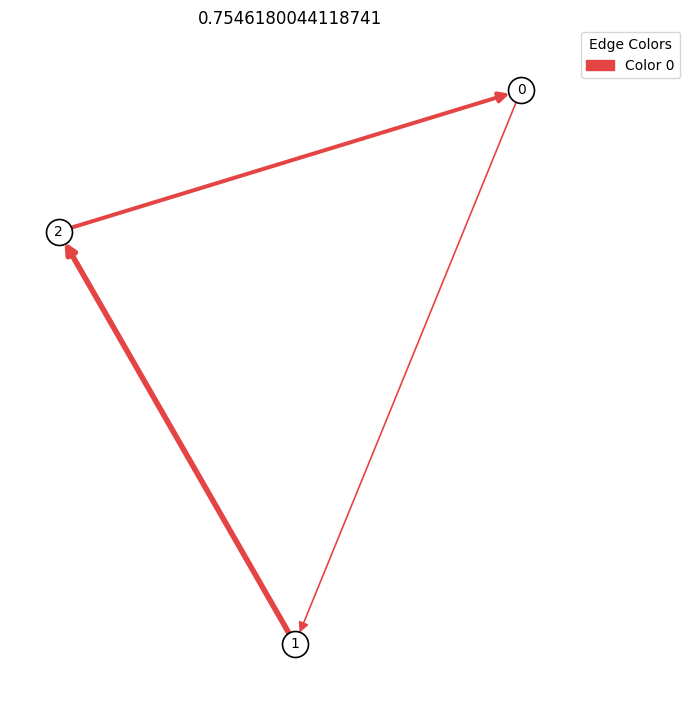

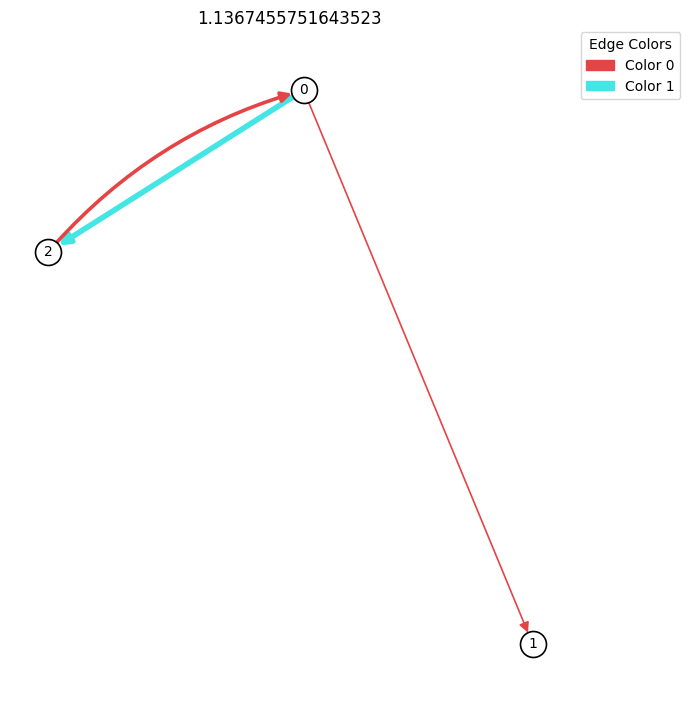

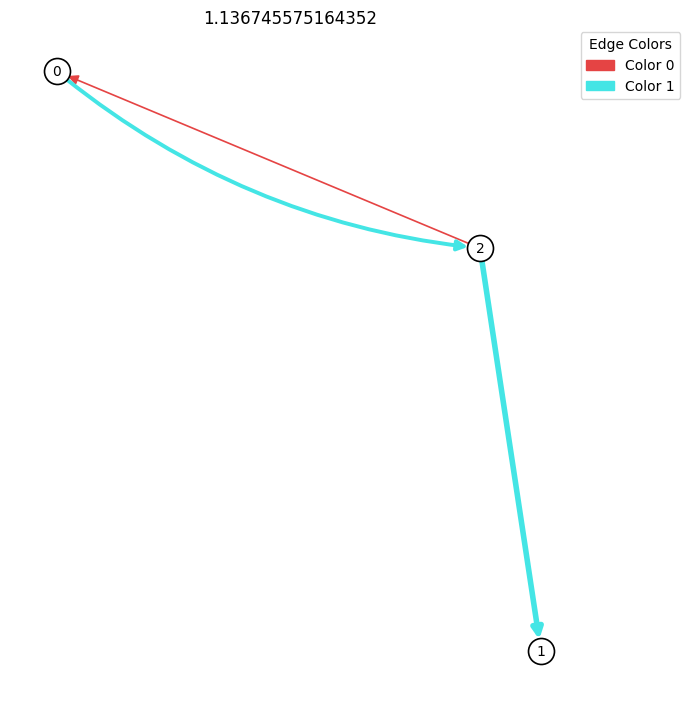

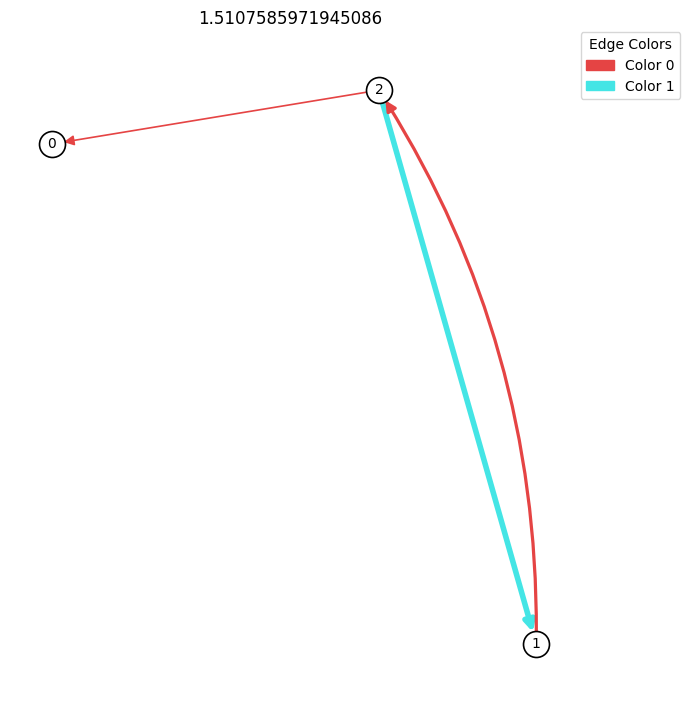

In [50]:
print(len(n1.subnetworks))
n1.visualize_subnetworks()

3


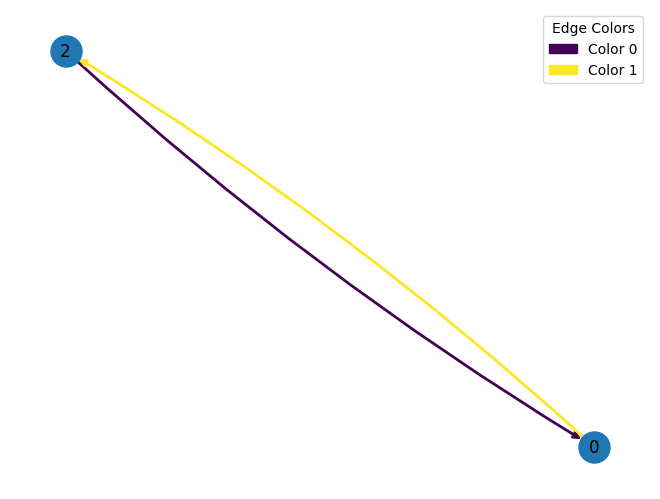

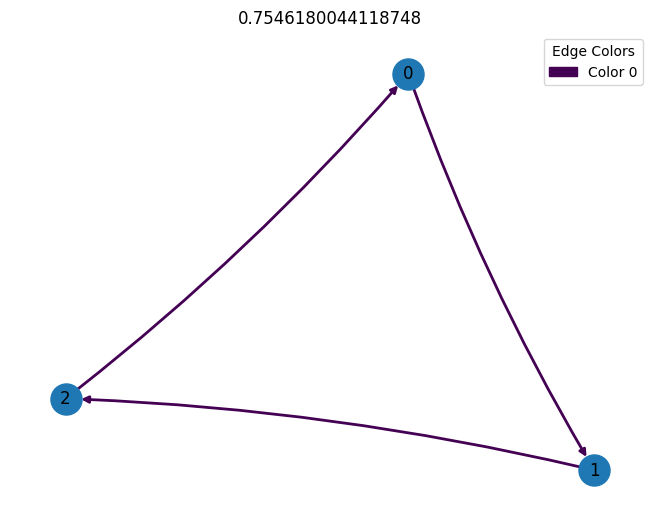

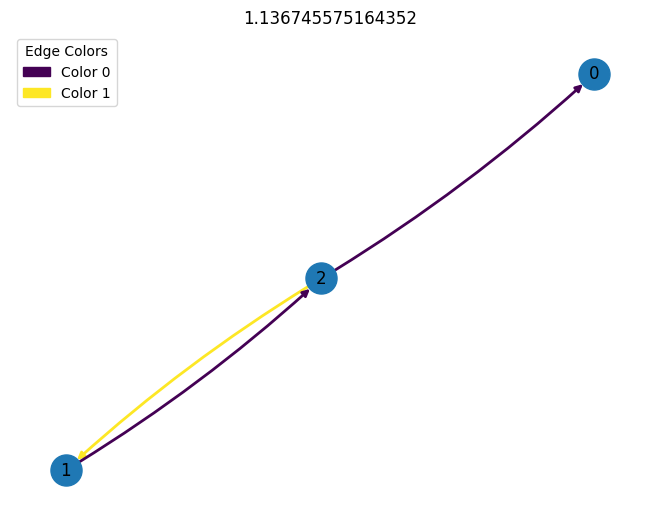

In [51]:
print(len(n2.subnetworks))
n2.visualize_subnetworks(n2.subnetworks)

In [2]:
star_times = []
bfs_times = [] 
col_vals = list(range(2, 9))

for col in col_vals:
    print(col)
    times_star = []
    times_bfs = []
    
    for _ in range(100):
        n1 = SupplyChainNetwork(10, 30, col)

        start = perf_counter()
        n1.calculate_subnetworks()
        end = perf_counter()

        times_star.append(end - start)

        start = perf_counter()
        n2 = Graphclass(10, 30, col, method="goliath")
        end = perf_counter()

        times_bfs.append(end - start)

    star_times.append(np.mean(times_star))
    bfs_times.append(np.mean(times_bfs))


2
3
4
5
6
7
8


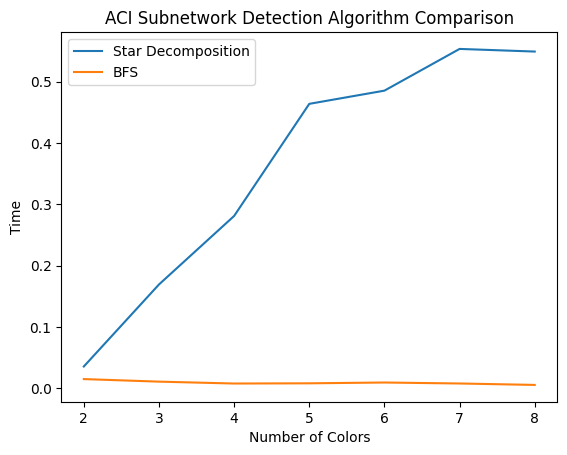

In [3]:
plt.plot(col_vals, star_times, label="Star Decomposition")
plt.plot(col_vals, bfs_times, label="BFS")

plt.xlabel("Number of Colors")
plt.ylabel("Time")
plt.title("ACI Subnetwork Detection Algorithm Comparison")

plt.legend()
plt.show()

In [5]:
n_vals = list(range(5, 31))
bloomberg_edge_coeff = np.log(sc.num_edges) / np.log(sc.num_nodes)
star_times = []
bfs_times = []

for n in n_vals:
    print(n)
    m = int(n**bloomberg_edge_coeff)
    times_star = []
    times_bfs = []

    for _ in range(100):
    
        n1 = SupplyChainNetwork(n, m, sc.num_colors)

        start = perf_counter()
        n1.calculate_subnetworks()
        end = perf_counter()

        times_star.append(end - start)

        n2 = Graphclass(n, m, sc.num_colors, method="goliath")
        
        start = perf_counter()
        n2.breadth_first()
        end = perf_counter()

        times_bfs.append(end - start)

    star_times.append(np.median(times_star))
    bfs_times.append(np.median(times_bfs))


5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30


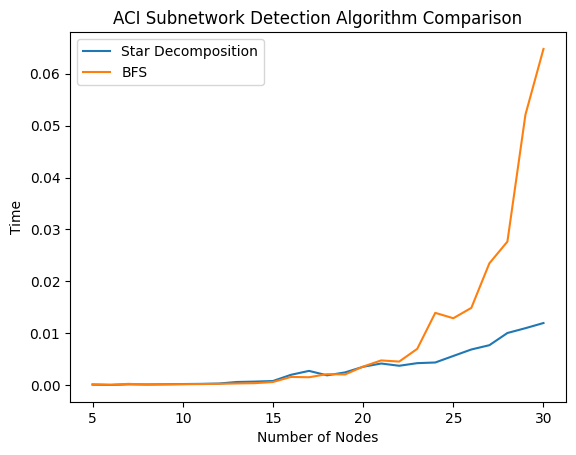

In [6]:
plt.plot(n_vals, star_times, label="Star Decomposition")
plt.plot(n_vals, bfs_times, label="BFS")

plt.xlabel("Number of Nodes")
plt.ylabel("Time")
plt.title("ACI Subnetwork Detection Algorithm Comparison")

plt.legend()
plt.show()

In [2]:
n_vals = list(range(5, 27))
star_times = []
bfs_times = []

for n in n_vals:
    print(n)
    times_star = []
    times_bfs = []

    for _ in range(100):
        n1 = SupplyChainNetwork(n, 1, 8, method='scale_free')

        start = perf_counter()
        n1.calculate_subnetworks()
        end = perf_counter()

        times_star.append(end - start)

        n2 = Graphclass(1, 1, 1, "random")
        W = nx.to_numpy_array(n1.G, weight="weight")

        n2.use_premade(n1.G, W)
        
        start = perf_counter()
        n2.breadth_first()
        end = perf_counter()

        times_bfs.append(end - start)

    star_times.append(np.median(times_star))
    bfs_times.append(np.median(times_bfs))


5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26


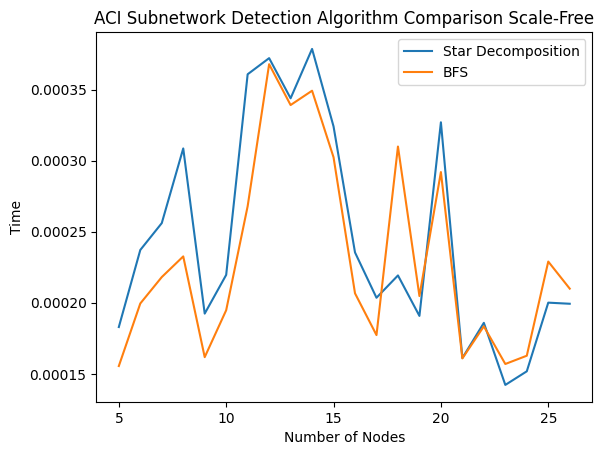

In [3]:
plt.plot(n_vals, star_times, label="Star Decomposition")
plt.plot(n_vals, bfs_times, label="BFS")

plt.xlabel("Number of Nodes")
plt.ylabel("Time")
plt.title("ACI Subnetwork Detection Algorithm Comparison Scale-Free")

plt.legend()
plt.show()

In [35]:
n_vals = list(range(10, 27))
star_times = []
bfs_times = []

for n in n_vals:
    print(n)
    times_star = []
    times_bfs = []

    for _ in range(100):
        n1 = SupplyChainNetwork(n, 1, 8, method='erdos')
        print(n1.G)

        start = perf_counter()
        n1.calculate_subnetworks()
        end = perf_counter()

        times_star.append(end - start)
        print(n1.G.nodes)

        n2 = Graphclass(1, 1, 1, "random")
        W = nx.to_numpy_array(n1.G, weight="weight")

        n2.use_premade(n1.G, W)
        
        start = perf_counter()
        n2.breadth_first()
        end = perf_counter()

        times_bfs.append(end - start)

    star_times.append(np.median(times_star))
    bfs_times.append(np.median(times_bfs))


10


NetworkXPointlessConcept: Connectivity is undefined for the null graph.

In [37]:
G = nx.erdos_renyi_graph(50, 0.05)
len(G.nodes)

50

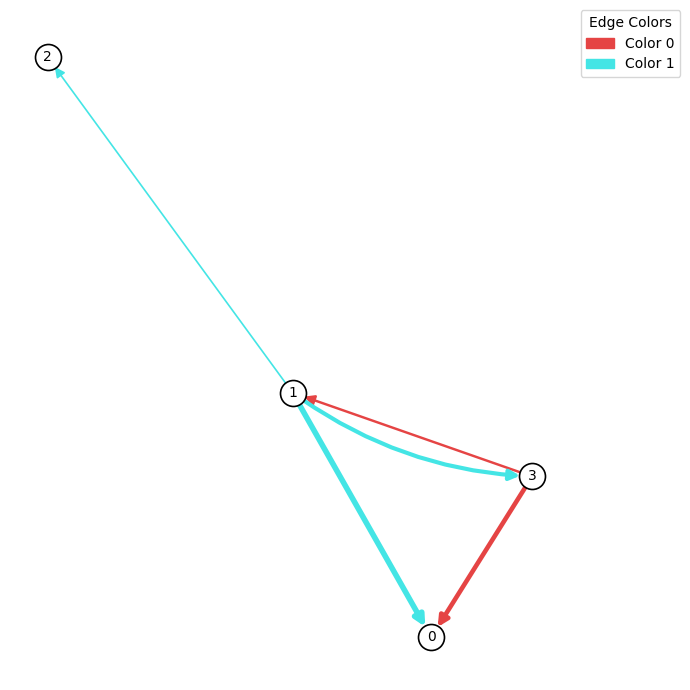

In [27]:
s = SupplyChainNetwork.generate(num_nodes=4, num_edges=5, num_colors=2)
s.visualize_supply_chain()

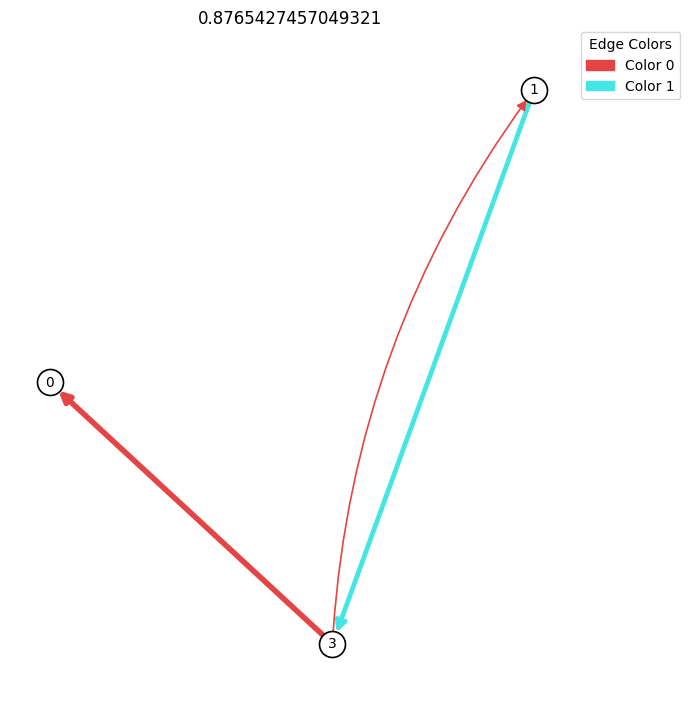

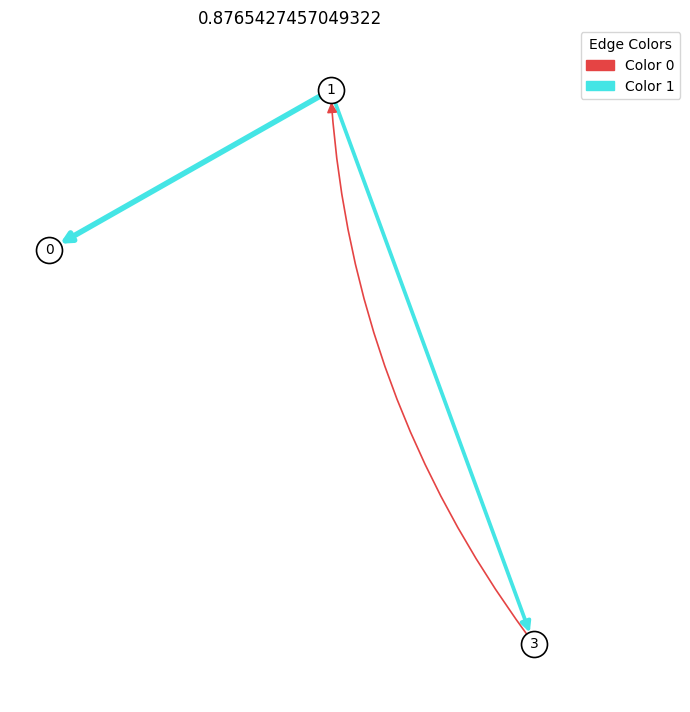

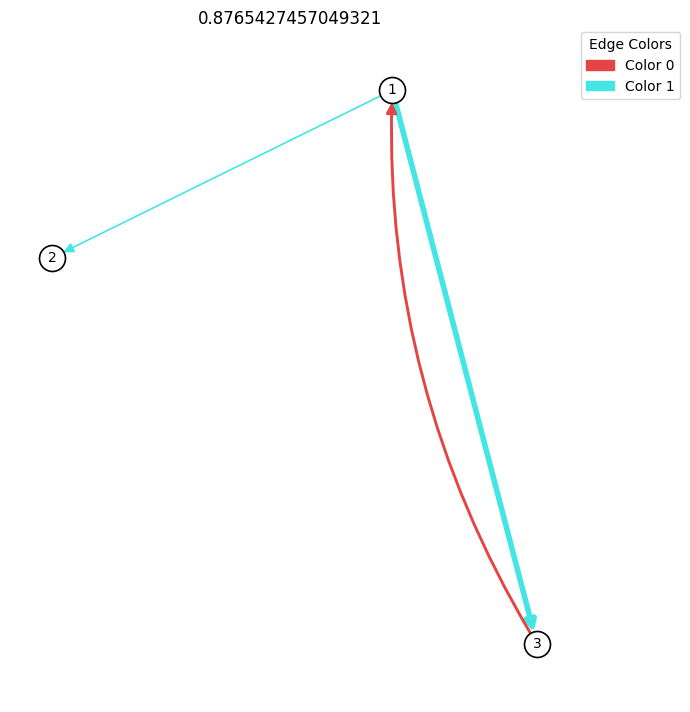

In [28]:
s.visualize_subnetworks()